# DatasetとDataloader

## Dataset

In [83]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
import torch

In [57]:
train_dataset = torchvision.datasets.MNIST(root = './mnist_data', train = True, download = True)

In [58]:
import sys
sys.getsizeof(train_dataset) # 48バイト

48

In [59]:
image, label = train_dataset[0]

In [60]:
image # PIL形式

In [61]:
type(image)

PIL.Image.Image

In [62]:
label

5

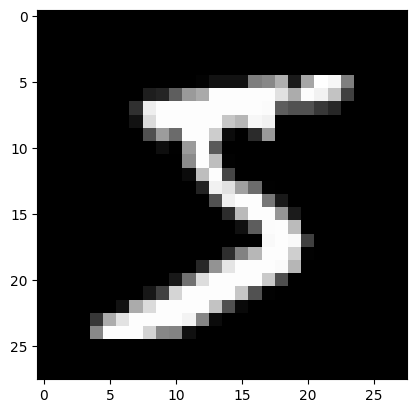

In [63]:
plt.imshow(image, cmap = 'gray')

## Transform

In [64]:
image

In [65]:
# .ToTensor()
image_tensor = torchvision.transforms.ToTensor()(image)

In [22]:
type(image_tensor)

torch.Tensor

In [25]:
image_tensor.shape

torch.Size([1, 28, 28])

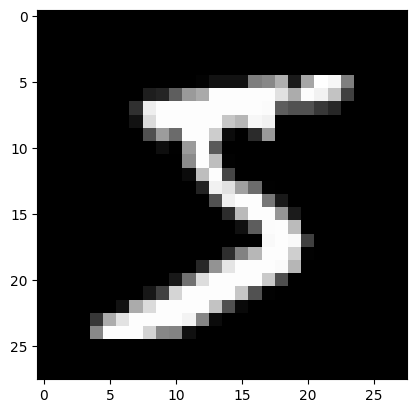

In [33]:
plt.imshow(image_tensor[0], cmap = 'gray')

In [48]:
# .Normalize()
normalized_image_tensor = transforms.Normalize((0.5,), (0.5,))(image_tensor) # 1-から1に正規化
normalized_image_tensor

tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1

In [67]:
# .Compose()
transform = transforms.Compose([torchvision.transforms.ToTensor(), 
                                            transforms.Normalize((0.5,), (0.5,))])
transformed_image = transform(image)

In [68]:
transformed_image.shape

torch.Size([1, 28, 28])

In [71]:
train_dataset = torchvision.datasets.MNIST(root = './mnist_data', train = True, download = True, transform = transform)
val_dataset = torchvision.datasets.MNIST(root = './mnist_data', train = False, download = True, transform = transform)

In [70]:
image, label = train_dataset[0]
image

tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1

## Dataloader

In [75]:
train_loader = DataLoader(train_dataset, batch_size = 10, shuffle = True, num_workers = 2)
val_loader = DataLoader(val_dataset, batch_size = 10, num_workers = 2)

In [77]:
train_loader

In [79]:
images, labels = next(iter(train_loader))
print(images.shape) # バッチサイズ, チャネル数, 縦, 横 で出力

torch.Size([10, 1, 28, 28])


In [81]:
grid_images = torchvision.utils.make_grid(images)

In [82]:
grid_images.shape

torch.Size([3, 62, 242])

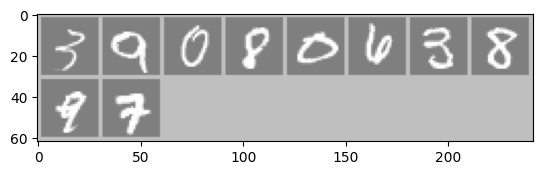

In [87]:
grid_images = grid_images / 2 + 0.5 # 正規化されているデータを元に戻している
plt.imshow(torch.permute(grid_images, dims = (1, 2, 0)))

In [86]:
labels

tensor([3, 9, 0, 8, 0, 6, 3, 8, 9, 7])